# Exploratory Data Analysis: Movie Release Scale and Domestic Box Office

Research question for the regression stage:

**How is the number of theaters in which a movie is released associated with domestic box office revenue, after controlling for production budget, genre, MPAA rating, release timing, and production characteristics?**

This notebook focuses on four EDA tasks:

1. Inspect the dataset structure and data quality.
2. Check skewness in the main revenue, budget, and theater-count variables.
3. Visualize the relationship between theater count and domestic box office revenue.
4. Identify control variables that look relevant for the regression specification.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

DATA_PATH = Path("../data/top_movies_cleaned_eda.csv")
df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()


Rows: 4,480
Columns: 28


,movie_name,release_date,release_year,release_month,release_quarter,production_budget_usd,domestic_box_office_usd,international_box_office_usd,worldwide_box_office_usd,opening_weekend_usd,...,running_time_minutes,domestic_share_percentage,legs,is_franchise,log_domestic_box_office,log_worldwide_box_office,log_budget,log_opening_weekend,log_opening_theaters,log_max_theaters
0,Star Wars Ep. VII: The Force Awakens,2015-12-16,2015.0,12.0,4.0,533200000,936662225.0,1.119385e+09,2.056047e+09,247966675.0,...,136.0,45.6,3.78,1,20.657833,21.444051,20.094407,19.328805,8.327243,8.327243
1,Avatar: The Way of Water,2022-12-09,2022.0,12.0,4.0,460000000,684075767.0,1.631514e+09,2.315590e+09,134100226.0,...,190.0,29.5,5.10,1,20.343579,21.562930,19.946737,18.714098,8.343554,8.375860
2,Indiana Jones and the Dial of Destiny,2023-06-28,2023.0,6.0,2.0,402300000,174480468.0,2.094826e+08,3.839631e+08,60368101.0,...,142.0,45.4,2.89,1,18.977323,19.766057,19.812709,17.915971,8.434029,8.434029
3,Avengers: Endgame,2019-04-23,2019.0,4.0,2.0,400000000,858373000.0,1.889870e+09,2.748243e+09,357115007.0,...,181.0,31.2,2.40,1,20.570549,21.734228,19.806975,19.693568,8.447414,8.447414
4,Pirates of the Caribbean: On Stranger Tides,2011-05-20,2011.0,5.0,2.0,379000000,241071802.0,8.046420e+08,1.045714e+09,90151958.0,...,136.0,23.1,2.67,1,19.300605,20.767966,19.753047,18.317007,8.332308,8.334472


## 1. Dataset Structure

The dataset contains movie-level observations. The outcome for the planned regression is domestic box office revenue. The focal explanatory variable is `opening_theaters`, which represents the initial release scale. The dataset also includes budget, release timing, categorical production characteristics, and pre-computed log transforms.


In [2]:
column_overview = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "missing": df.isna().sum().values,
    "missing_pct": (df.isna().mean().values * 100).round(2),
    "unique_values": df.nunique(dropna=False).values,
})
column_overview


,column,dtype,non_null,missing,missing_pct,unique_values
0,movie_name,str,4480,0,0.0,4433
1,release_date,str,4480,0,0.0,2384
2,release_year,float64,4480,0,0.0,53
3,release_month,float64,4480,0,0.0,12
4,release_quarter,float64,4480,0,0.0,4
5,production_budget_usd,int64,4480,0,0.0,419
6,domestic_box_office_usd,float64,4480,0,0.0,4479
7,international_box_office_usd,float64,4480,0,0.0,4350
8,worldwide_box_office_usd,float64,4480,0,0.0,4478
9,opening_weekend_usd,float64,4480,0,0.0,4477


In [3]:
print(f"Duplicate movie names: {df['movie_name'].duplicated().sum():,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")

key_columns = [
    "movie_name", "release_date", "release_year", "release_quarter",
    "production_budget_usd", "domestic_box_office_usd", "opening_theaters",
    "max_theaters", "mpaa_rating", "genre", "source", "production_method",
    "creative_type", "running_time_minutes", "is_franchise"
]

df[key_columns].sample(10, random_state=42)


Duplicate movie names: 47
Duplicate rows: 0


,movie_name,release_date,release_year,release_quarter,production_budget_usd,domestic_box_office_usd,opening_theaters,max_theaters,mpaa_rating,genre,source,production_method,creative_type,running_time_minutes,is_franchise
157,Waterworld,1995-07-28,1995.0,3.0,175000000,88246220.0,2268.0,2420.0,PG-13,Action,Original Screenplay,Live Action,Science Fiction,135.0,0
4104,Hard Eight,1997-02-28,1997.0,1.0,3000000,142356.0,29.0,29.0,R,Drama,Original Screenplay,Live Action,Contemporary Fiction,95.0,0
1018,Joy,2015-12-24,2015.0,4.0,60000000,56451232.0,2896.0,2924.0,PG-13,Drama,Based on Real Life Events,Live Action,Dramatization,124.0,0
1117,Pocahontas,1995-06-10,1995.0,2.0,55000000,141579773.0,6.0,2757.0,G,Adventure,Based on Real Life Events,Hand Animation,Historical Fiction,81.0,0
731,Jack and Jill,2011-11-11,2011.0,4.0,79000000,74158157.0,3438.0,3438.0,PG,Comedy,Original Screenplay,Live Action,Contemporary Fiction,90.0,0
2676,All Good Things,2010-12-03,2010.0,4.0,20000000,582024.0,2.0,35.0,R,Drama,Original Screenplay,Live Action,Contemporary Fiction,101.0,0
4113,Hustle & Flow,2005-07-22,2005.0,3.0,2800000,22202809.0,1013.0,1016.0,R,Drama,Original Screenplay,Live Action,Contemporary Fiction,116.0,0
3887,Moon,2009-06-12,2009.0,2.0,5000000,5010163.0,8.0,251.0,R,Thriller/Suspense,Original Screenplay,Live Action,Science Fiction,97.0,0
1038,Star Trek: Nemesis,2002-12-13,2002.0,4.0,60000000,43254409.0,2711.0,2711.0,PG-13,Adventure,Based on TV,Live Action,Science Fiction,116.0,1
1434,Paws of Fury: The Legend of Hank,2022-07-15,2022.0,3.0,45000000,17811382.0,3475.0,3481.0,PG,Adventure,Based on Movie,Digital Animation,Kids Fiction,97.0,0


In [4]:
def compact_usd(x):
    if pd.isna(x):
        return ""
    if abs(x) >= 1_000_000_000:
        return f"${x / 1_000_000_000:,.2f}B"
    if abs(x) >= 1_000_000:
        return f"${x / 1_000_000:,.1f}M"
    if abs(x) >= 1_000:
        return f"${x / 1_000:,.1f}K"
    return f"${x:,.0f}"

main_numeric = [
    "domestic_box_office_usd", "worldwide_box_office_usd", "production_budget_usd",
    "opening_weekend_usd", "opening_theaters", "max_theaters",
    "running_time_minutes", "avg_weeks_per_theater", "legs"
]

summary = df[main_numeric].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
summary[["mean", "std", "min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max"]]


,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
domestic_box_office_usd,5.764449e+07,8.317321e+07,264.0,16876.0400,205322.60,7852404.00,30894556.50,7.112215e+07,2.085697e+08,4.080262e+08,9.366622e+08
worldwide_box_office_usd,1.322851e+08,2.164064e+08,10679.0,116953.2700,1109999.80,16903626.00,55617094.00,1.562717e+08,5.272725e+08,1.046529e+09,2.923706e+09
production_budget_usd,4.284373e+07,4.984044e+07,6000.0,250000.0000,1500000.00,10000000.00,25000000.00,5.500000e+07,1.500000e+08,2.176300e+08,5.332000e+08
opening_weekend_usd,1.566736e+07,2.502819e+07,24.0,4647.0100,23842.40,401161.50,8308613.50,1.929472e+07,5.725651e+07,1.307193e+08,3.571150e+08
opening_theaters,1.906879e+03,1.425347e+03,1.0,1.0000,2.00,39.00,2306.50,3.056000e+03,3.972300e+03,4.345000e+03,4.735000e+03
max_theaters,2.100494e+03,1.305806e+03,1.0,4.0000,24.00,868.75,2421.00,3.113250e+03,3.992250e+03,4.347210e+03,4.802000e+03
running_time_minutes,1.095596e+02,1.865696e+01,42.0,80.0000,86.00,96.00,107.00,1.190000e+02,1.430000e+02,1.690000e+02,2.510000e+02
avg_weeks_per_theater,5.374129e+00,3.125649e+00,0.0,1.0000,2.00,3.40,4.80,6.600000e+00,1.030000e+01,1.640000e+01,6.410000e+01
legs,4.880790e+00,1.588521e+01,1.0,1.4116,1.96,2.56,3.33,5.000000e+00,1.126050e+01,1.793210e+01,9.983300e+02


The data quality check indicates that the cleaned EDA file is already complete for the variables used here. A few categorical variables have rare categories, especially MPAA rating strings and production characteristics, so grouped versions are useful for EDA and regression dummy variables.


In [5]:
def clean_rating(value):
    value = str(value).strip()
    if value.startswith("PG-13"):
        return "PG-13"
    if value.startswith("PG"):
        return "PG"
    if value.startswith("R"):
        return "R"
    if value.startswith("G"):
        return "G"
    if value.startswith("NC-17"):
        return "NC-17"
    return "Not Rated / Other"

def collapse_rare_categories(series, min_count=30, other_label="Other"):
    counts = series.value_counts(dropna=False)
    keep = counts[counts >= min_count].index
    return series.where(series.isin(keep), other_label)

eda = df.copy()
eda["release_date"] = pd.to_datetime(eda["release_date"])
eda["release_year"] = eda["release_year"].astype(int)
eda["release_month"] = eda["release_month"].astype(int)
eda["release_quarter"] = eda["release_quarter"].astype(int)
eda["rating_group"] = eda["mpaa_rating"].apply(clean_rating)
eda["genre_grouped"] = collapse_rare_categories(eda["genre"], min_count=40)
eda["source_grouped"] = collapse_rare_categories(eda["source"], min_count=50)
eda["production_method_grouped"] = collapse_rare_categories(eda["production_method"], min_count=40)
eda["creative_type_grouped"] = collapse_rare_categories(eda["creative_type"], min_count=40)
eda["franchise_label"] = eda["is_franchise"].map({0: "Standalone", 1: "Franchise"})

cat_cols = [
    "rating_group", "genre_grouped", "release_quarter", "production_method_grouped",
    "creative_type_grouped", "source_grouped", "franchise_label"
]

for col in cat_cols:
    print("\n" + str(col))
    print(eda[col].value_counts().head(20).to_string())



rating_group
rating_group
R                    1943
PG-13                1612
PG                    689
Not Rated / Other     144
G                      86
NC-17                   6

genre_grouped
genre_grouped
Drama                1150
Comedy                739
Action                649
Adventure             576
Thriller/Suspense     479
Horror                381
Romantic Comedy       223
Black Comedy           99
Musical                68
Documentary            60
Western                41
Other                  15

release_quarter
release_quarter
4    1339
3    1169
2    1065
1     907

production_method_grouped
production_method_grouped
Live Action              4009
Digital Animation         207
Animation,Live Action     188
Hand Animation             57
Other                      19

creative_type_grouped
creative_type_grouped
Contemporary Fiction    2302
Historical Fiction       477
Dramatization            431
Science Fiction          417
Kids Fiction             320
Fantasy   

## 2. Skewness of Main Variables

Box office revenue, budgets, and opening weekend revenue are usually heavy-tailed: a small number of very large movies can dominate the raw scale. The existing log variables help make the distributions more comparable and better suited for linear regression.


In [6]:
skew_pairs = [
    ("domestic_box_office_usd", "log_domestic_box_office"),
    ("worldwide_box_office_usd", "log_worldwide_box_office"),
    ("production_budget_usd", "log_budget"),
    ("opening_weekend_usd", "log_opening_weekend"),
    ("opening_theaters", "log_opening_theaters"),
    ("max_theaters", "log_max_theaters"),
]

skew_table = []
for raw, logged in skew_pairs:
    skew_table.append({
        "variable": raw,
        "raw_skew": eda[raw].skew(),
        "log_variable": logged,
        "log_skew": eda[logged].skew(),
        "raw_median": eda[raw].median(),
        "raw_95th_pct": eda[raw].quantile(.95),
    })

skew_table = pd.DataFrame(skew_table)
skew_table["raw_skew"] = skew_table["raw_skew"].round(3)
skew_table["log_skew"] = skew_table["log_skew"].round(3)
skew_table


,variable,raw_skew,log_variable,log_skew,raw_median,raw_95th_pct
0,domestic_box_office_usd,3.542,log_domestic_box_office,-1.426,30894556.5,2.085697e+08
1,worldwide_box_office_usd,4.125,log_worldwide_box_office,-0.970,55617094.0,5.272725e+08
2,production_budget_usd,2.431,log_budget,-1.075,25000000.0,1.500000e+08
3,opening_weekend_usd,4.136,log_opening_weekend,-0.908,8308613.5,5.725651e+07
4,opening_theaters,-0.172,log_opening_theaters,-1.022,2306.5,3.972300e+03
5,max_theaters,-0.278,log_max_theaters,-1.796,2421.0,3.992250e+03


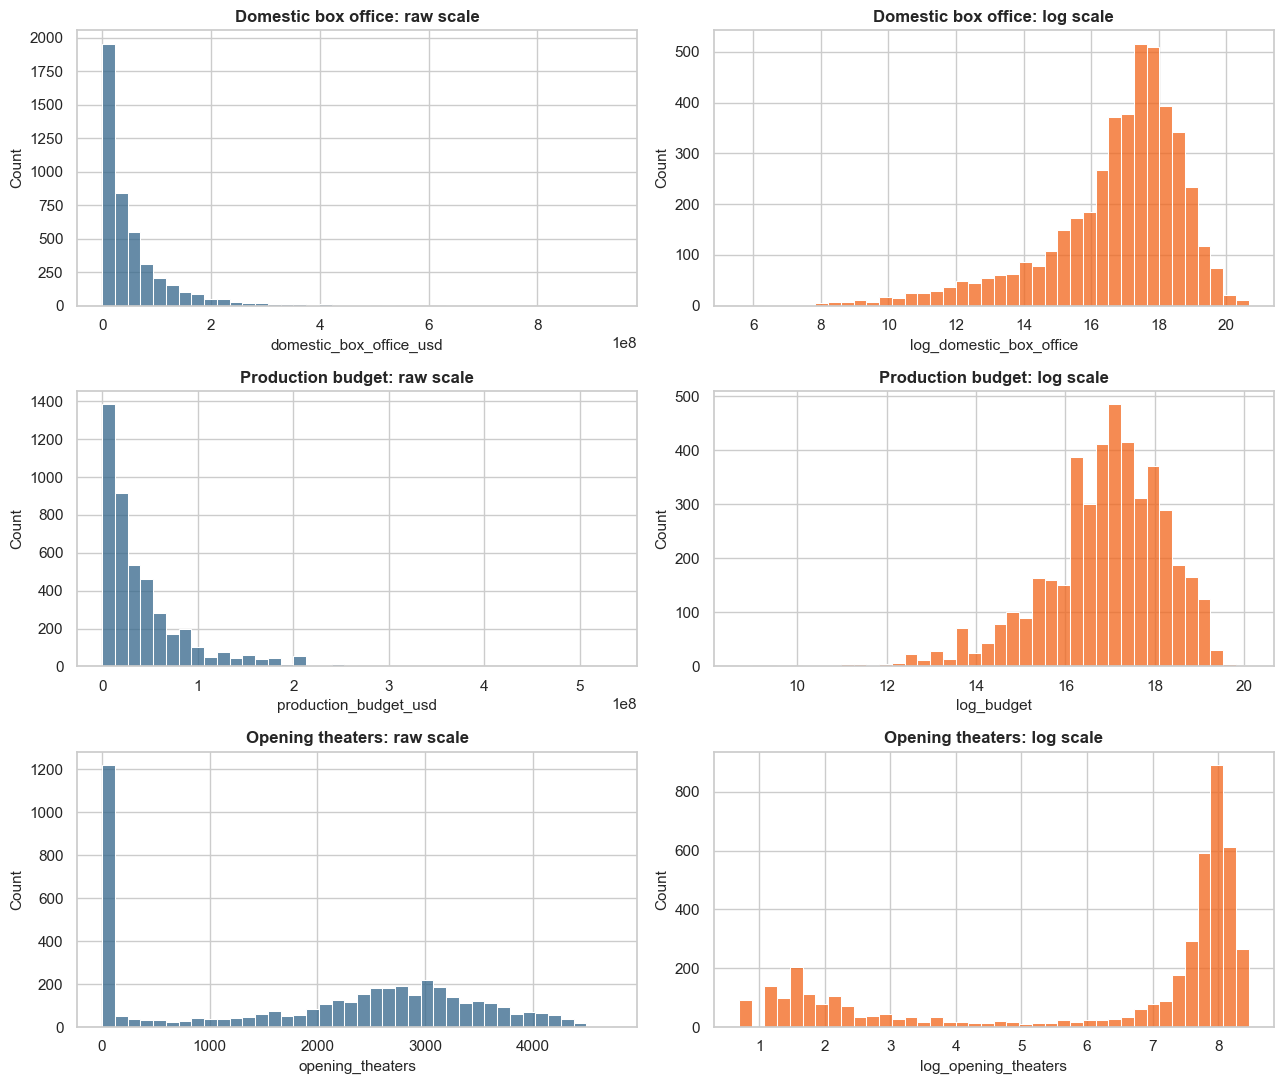

In [7]:
plot_pairs = [
    ("domestic_box_office_usd", "log_domestic_box_office", "Domestic box office"),
    ("production_budget_usd", "log_budget", "Production budget"),
    ("opening_theaters", "log_opening_theaters", "Opening theaters"),
]

fig, axes = plt.subplots(len(plot_pairs), 2, figsize=(13, 11))
for i, (raw, logged, title) in enumerate(plot_pairs):
    sns.histplot(eda[raw], bins=40, ax=axes[i, 0], color="#33658A")
    axes[i, 0].set_title(f"{title}: raw scale")
    axes[i, 0].set_xlabel(raw)

    sns.histplot(eda[logged], bins=40, ax=axes[i, 1], color="#F26419")
    axes[i, 1].set_title(f"{title}: log scale")
    axes[i, 1].set_xlabel(logged)

plt.tight_layout()
plt.show()


The domestic box office and budget variables are strongly right-skewed on the dollar scale. The theater-count variable is less skewed than revenue, but its log version is still useful for a log-log regression because it makes the focal coefficient interpretable as an elasticity.


## 3. Theater Count and Domestic Box Office

The core bivariate relationship is positive: movies released in more theaters tend to earn more domestically. Because wide releases and large budgets are related, this pattern should be evaluated again after controlling for budget and movie characteristics.


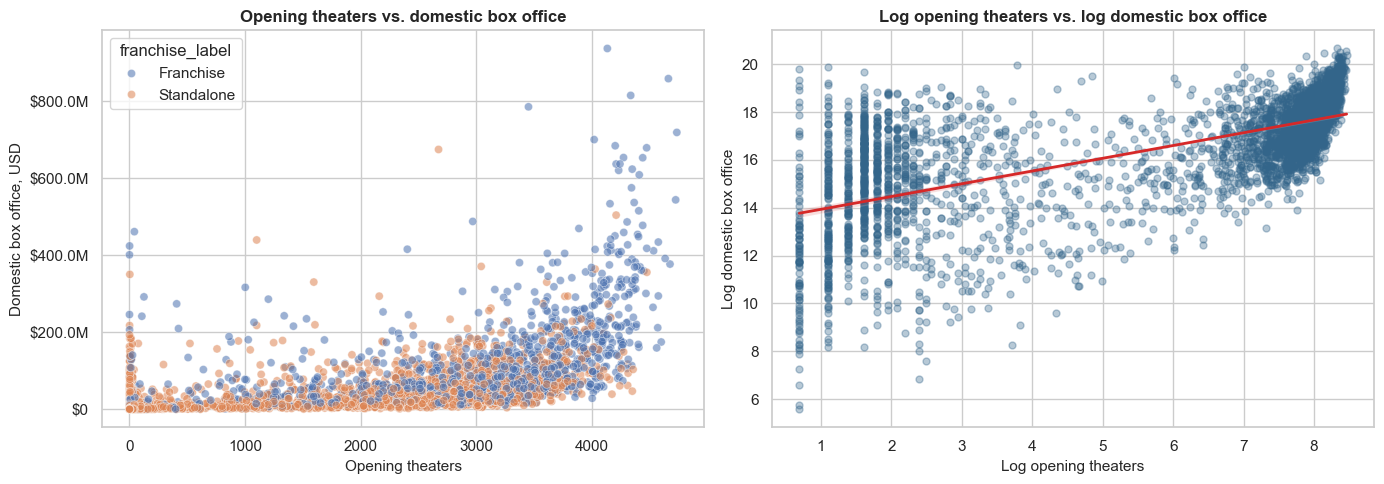

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=eda,
    x="opening_theaters",
    y="domestic_box_office_usd",
    hue="franchise_label",
    alpha=0.55,
    s=35,
    ax=axes[0],
)
axes[0].set_title("Opening theaters vs. domestic box office")
axes[0].set_xlabel("Opening theaters")
axes[0].set_ylabel("Domestic box office, USD")
axes[0].yaxis.set_major_formatter(lambda x, pos: compact_usd(x))

sns.regplot(
    data=eda,
    x="log_opening_theaters",
    y="log_domestic_box_office",
    scatter_kws={"alpha": 0.35, "s": 25, "color": "#33658A"},
    line_kws={"color": "#D62828", "linewidth": 2},
    ax=axes[1],
)
axes[1].set_title("Log opening theaters vs. log domestic box office")
axes[1].set_xlabel("Log opening theaters")
axes[1].set_ylabel("Log domestic box office")

plt.tight_layout()
plt.show()


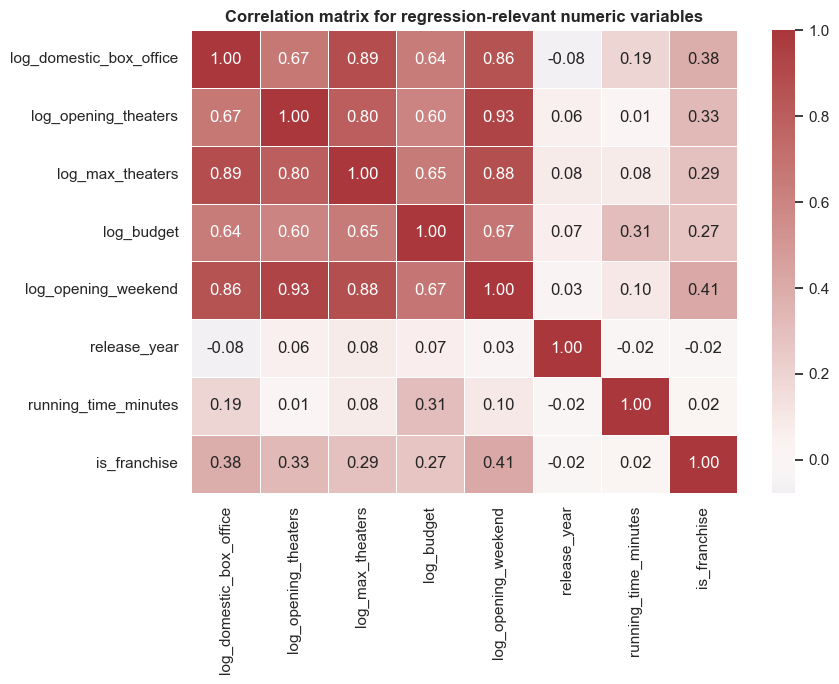

,corr_with_log_domestic
log_domestic_box_office,1.000000
log_max_theaters,0.889440
log_opening_weekend,0.861254
log_opening_theaters,0.667048
log_budget,0.640899
is_franchise,0.382910
running_time_minutes,0.190449
release_year,-0.076472


In [9]:
correlation_vars = [
    "log_domestic_box_office", "log_opening_theaters", "log_max_theaters",
    "log_budget", "log_opening_weekend", "release_year", "running_time_minutes",
    "is_franchise"
]

corr = eda[correlation_vars].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=.5)
plt.title("Correlation matrix for regression-relevant numeric variables")
plt.tight_layout()
plt.show()

corr["log_domestic_box_office"].sort_values(ascending=False).to_frame("corr_with_log_domestic")


In [10]:
eda["opening_theater_quartile"] = pd.qcut(
    eda["opening_theaters"],
    q=4,
    labels=["Q1 smallest", "Q2", "Q3", "Q4 widest"]
)

theater_bin_summary = eda.groupby("opening_theater_quartile", observed=True).agg(
    movies=("movie_name", "count"),
    median_opening_theaters=("opening_theaters", "median"),
    median_domestic_box_office=("domestic_box_office_usd", "median"),
    mean_log_domestic=("log_domestic_box_office", "mean"),
    median_budget=("production_budget_usd", "median"),
    franchise_share=("is_franchise", "mean"),
).reset_index()

theater_bin_summary["franchise_share"] = (theater_bin_summary["franchise_share"] * 100).round(1)
theater_bin_summary["median_domestic_box_office_fmt"] = theater_bin_summary["median_domestic_box_office"].map(compact_usd)
theater_bin_summary["median_budget_fmt"] = theater_bin_summary["median_budget"].map(compact_usd)
theater_bin_summary


,opening_theater_quartile,movies,median_opening_theaters,median_domestic_box_office,mean_log_domestic,median_budget,franchise_share,median_domestic_box_office_fmt,median_budget_fmt
0,Q1 smallest,1121,5.0,3067312.0,14.599668,8000000.0,4.5,$3.1M,$8.0M
1,Q2,1119,1511.0,15567860.0,16.388002,17000000.0,20.6,$15.6M,$17.0M
2,Q3,1121,2707.0,38530322.0,17.461365,33000000.0,24.8,$38.5M,$33.0M
3,Q4 widest,1119,3509.0,95159005.0,18.381219,80000000.0,55.9,$95.2M,$80.0M


The binned table is useful because it shows the confounding problem directly. The widest-release quartile has higher domestic revenue, but it also tends to have larger budgets and a higher franchise share. Those factors should be controlled for in the regression.


## 4. Candidate Control Variables

Good controls should usually be measured before, or at the time of, release. For the planned regression, the strongest candidates are production budget, genre, MPAA rating, release timing, source, production method, creative type, franchise status, runtime, and release year.

Variables such as `opening_weekend_usd`, `max_theaters`, `avg_weeks_per_theater`, `legs`, `domestic_share_percentage`, international box office, and worldwide box office are useful descriptively but should be treated carefully in the main model. They are partly post-release outcomes or closely tied to the dependent variable.


In [11]:
def category_summary(data, category, min_count=10):
    out = data.groupby(category).agg(
        movies=("movie_name", "count"),
        median_domestic=("domestic_box_office_usd", "median"),
        mean_log_domestic=("log_domestic_box_office", "mean"),
        median_opening_theaters=("opening_theaters", "median"),
        median_budget=("production_budget_usd", "median"),
        franchise_share=("is_franchise", "mean"),
    ).query("movies >= @min_count").sort_values("mean_log_domestic", ascending=False)
    out["median_domestic_fmt"] = out["median_domestic"].map(compact_usd)
    out["median_budget_fmt"] = out["median_budget"].map(compact_usd)
    out["franchise_share"] = (out["franchise_share"] * 100).round(1)
    return out

category_summary(eda, "genre_grouped", min_count=10)


,movies,median_domestic,mean_log_domestic,median_opening_theaters,median_budget,franchise_share,median_domestic_fmt,median_budget_fmt
genre_grouped,,,,,,,,
Adventure,576,81832083.0,17.962880,3307.5,76000000.0,52.4,$81.8M,$76.0M
Action,649,53715611.0,17.525099,2908.0,65000000.0,52.2,$53.7M,$65.0M
Musical,68,40002327.5,16.849528,864.0,47500000.0,27.9,$40.0M,$47.5M
Other,15,28873374.0,16.820519,2040.0,10000000.0,20.0,$28.9M,$10.0M
Comedy,739,32122249.0,16.779946,2401.0,21000000.0,24.6,$32.1M,$21.0M
Romantic Comedy,223,31726995.0,16.761815,2332.0,25000000.0,7.2,$31.7M,$25.0M
Horror,381,30113491.0,16.707886,2571.0,15000000.0,48.6,$30.1M,$15.0M
Western,41,42720965.0,16.641092,2019.0,38000000.0,12.2,$42.7M,$38.0M
Thriller/Suspense,479,24375436.0,16.323641,2281.0,27000000.0,12.9,$24.4M,$27.0M


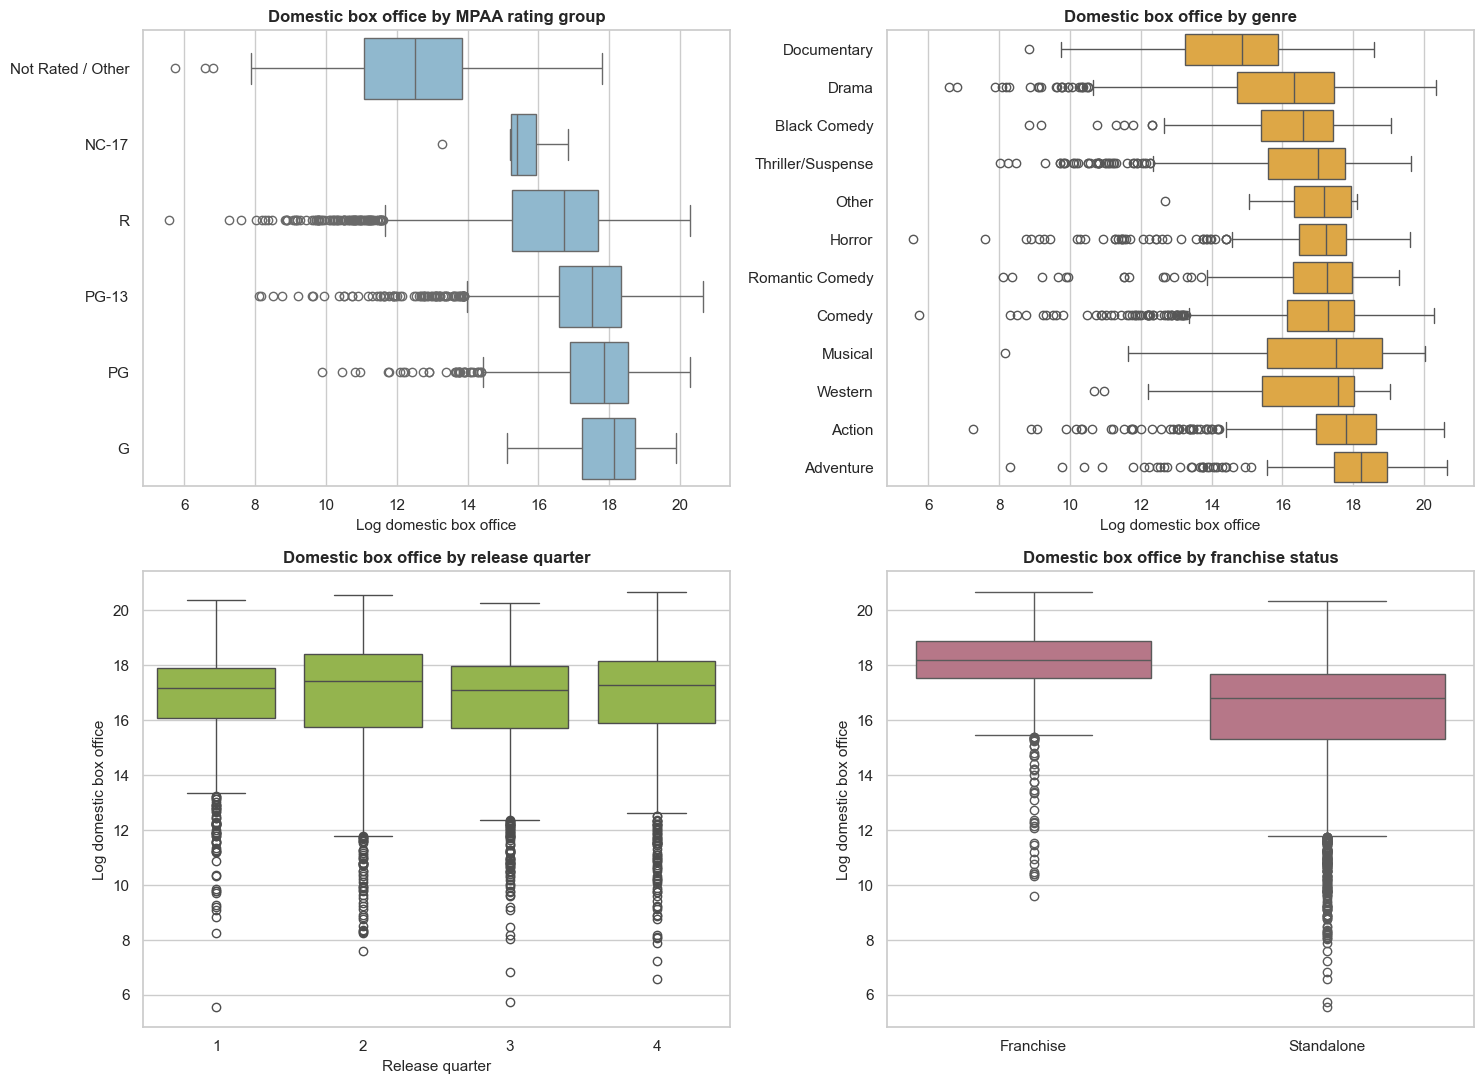

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

rating_order = eda.groupby("rating_group")["log_domestic_box_office"].median().sort_values().index
sns.boxplot(data=eda, x="log_domestic_box_office", y="rating_group", order=rating_order, ax=axes[0, 0], color="#86BBD8")
axes[0, 0].set_title("Domestic box office by MPAA rating group")
axes[0, 0].set_xlabel("Log domestic box office")
axes[0, 0].set_ylabel("")

genre_order = eda.groupby("genre_grouped")["log_domestic_box_office"].median().sort_values().index
sns.boxplot(data=eda, x="log_domestic_box_office", y="genre_grouped", order=genre_order, ax=axes[0, 1], color="#F6AE2D")
axes[0, 1].set_title("Domestic box office by genre")
axes[0, 1].set_xlabel("Log domestic box office")
axes[0, 1].set_ylabel("")

quarter_order = sorted(eda["release_quarter"].unique())
sns.boxplot(data=eda, x="release_quarter", y="log_domestic_box_office", order=quarter_order, ax=axes[1, 0], color="#9BC53D")
axes[1, 0].set_title("Domestic box office by release quarter")
axes[1, 0].set_xlabel("Release quarter")
axes[1, 0].set_ylabel("Log domestic box office")

sns.boxplot(data=eda, x="franchise_label", y="log_domestic_box_office", ax=axes[1, 1], color="#C06C84")
axes[1, 1].set_title("Domestic box office by franchise status")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Log domestic box office")

plt.tight_layout()
plt.show()


In [13]:
control_tables = {
    "rating_group": category_summary(eda, "rating_group", min_count=1),
    "release_quarter": category_summary(eda, "release_quarter", min_count=1),
    "production_method_grouped": category_summary(eda, "production_method_grouped", min_count=1),
    "creative_type_grouped": category_summary(eda, "creative_type_grouped", min_count=1),
    "source_grouped": category_summary(eda, "source_grouped", min_count=1),
}

control_tables["rating_group"]


,movies,median_domestic,mean_log_domestic,median_opening_theaters,median_budget,franchise_share,median_domestic_fmt,median_budget_fmt
rating_group,,,,,,,,
G,86,76050755.0,17.988189,2649.5,38500000.0,53.5,$76.1M,$38.5M
PG,689,57012977.0,17.566245,2917.0,40000000.0,40.2,$57.0M,$40.0M
PG-13,1612,40930345.5,17.271722,2663.5,35000000.0,28.3,$40.9M,$35.0M
R,1943,18550030.0,16.198069,1525.0,18000000.0,20.1,$18.6M,$18.0M
NC-17,6,4908412.0,15.367651,7.0,5750000.0,16.7,$4.9M,$5.8M
Not Rated / Other,144,269473.5,12.430417,3.0,4550000.0,9.7,$269.5K,$4.5M


In [14]:
control_tables["release_quarter"]


,movies,median_domestic,mean_log_domestic,median_opening_theaters,median_budget,franchise_share,median_domestic_fmt,median_budget_fmt
release_quarter,,,,,,,,
2,1065,36931089.0,16.792738,2456.0,28000000.0,32.7,$36.9M,$28.0M
4,1339,31841299.0,16.773786,1925.0,26000000.0,23.9,$31.8M,$26.0M
1,907,28148130.0,16.723969,2470.0,24000000.0,24.7,$28.1M,$24.0M
3,1169,26947624.0,16.539068,2320.0,25000000.0,25.1,$26.9M,$25.0M


In [15]:
control_tables["production_method_grouped"]


,movies,median_domestic,mean_log_domestic,median_opening_theaters,median_budget,franchise_share,median_domestic_fmt,median_budget_fmt
production_method_grouped,,,,,,,,
"Animation,Live Action",188,143359752.0,18.582728,3700.0,123500000.0,67.6,$143.4M,$123.5M
Digital Animation,207,105806508.0,18.017390,3764.0,80000000.0,55.6,$105.8M,$80.0M
Hand Animation,57,43746923.0,16.831467,2179.0,28000000.0,36.8,$43.7M,$28.0M
Live Action,4009,26844692.0,16.551421,2135.0,23000000.0,22.9,$26.8M,$23.0M
Other,19,21002919.0,16.314806,2299.0,39000000.0,10.5,$21.0M,$39.0M


In [16]:
control_tables["creative_type_grouped"].head(15)


,movies,median_domestic,mean_log_domestic,median_opening_theaters,median_budget,franchise_share,median_domestic_fmt,median_budget_fmt
creative_type_grouped,,,,,,,,
Super Hero,131,162979405.0,18.648634,3882.0,130000000.0,84.0,$163.0M,$130.0M
Kids Fiction,320,83295507.0,17.992592,3455.5,70750000.0,55.0,$83.3M,$70.8M
Science Fiction,417,50586000.0,17.318857,2814.0,55000000.0,42.7,$50.6M,$55.0M
Fantasy,294,38449511.5,17.038675,2746.0,40000000.0,40.8,$38.4M,$40.0M
Contemporary Fiction,2302,26862179.0,16.509921,2206.5,20000000.0,22.4,$26.9M,$20.0M
Dramatization,431,19019882.0,16.397884,614.0,22000000.0,3.5,$19.0M,$22.0M
Historical Fiction,477,20182359.0,16.337784,613.0,26000000.0,12.8,$20.2M,$26.0M
Factual,76,4364754.0,14.966568,8.0,2000000.0,10.5,$4.4M,$2.0M
Other,32,348081.5,12.854172,5.5,2000000.0,6.2,$348.1K,$2.0M


In [17]:
control_tables["source_grouped"].head(15)


,movies,median_domestic,mean_log_domestic,median_opening_theaters,median_budget,franchise_share,median_domestic_fmt,median_budget_fmt
source_grouped,,,,,,,,
Based on Comic/Graphic Novel,188,103553664.0,18.229313,3557.5,100000000.0,70.2,$103.6M,$100.0M
Based on TV,148,71483185.0,17.663605,3038.5,46500000.0,52.7,$71.5M,$46.5M
Other,276,46759659.5,17.225533,2904.0,45000000.0,41.3,$46.8M,$45.0M
Remake,159,41778863.0,17.084783,2725.0,30000000.0,30.2,$41.8M,$30.0M
Based on Fiction Book/Short Story,841,34667015.0,16.994862,2296.0,34000000.0,24.6,$34.7M,$34.0M
Based on Factual Book/Article,145,33316821.0,16.976545,1987.0,30000000.0,10.3,$33.3M,$30.0M
Original Screenplay,2315,25440971.0,16.439230,2195.0,20000000.0,24.5,$25.4M,$20.0M
Based on Play,62,15124593.0,16.226502,25.5,13750000.0,16.1,$15.1M,$13.8M
Based on Real Life Events,346,13379439.5,15.947934,122.0,16250000.0,3.8,$13.4M,$16.2M


## 5. Regression-Oriented Diagnostic Model

This is not the final regression result. It is an EDA diagnostic to check whether the theater-count relationship remains visible after adding the main planned controls.

The dependent variable is `log_domestic_box_office`. The focal explanatory variable is `log_opening_theaters`, so the coefficient can be read approximately as the percent change in domestic box office associated with a 1 percent increase in opening theaters, conditional on the included controls.


In [18]:
model_data = eda.copy()

formula = """
log_domestic_box_office ~ log_opening_theaters + log_budget
+ C(genre_grouped) + C(rating_group) + C(release_quarter)
+ C(production_method_grouped) + C(creative_type_grouped) + C(source_grouped)
+ is_franchise + running_time_minutes + release_year
"""

eda_model = smf.ols(formula, data=model_data).fit(cov_type="HC3")

focus_terms = [
    "log_opening_theaters", "log_budget", "is_franchise",
    "running_time_minutes", "release_year"
]

coef_table = pd.DataFrame({
    "coef": eda_model.params,
    "robust_se": eda_model.bse,
    "p_value": eda_model.pvalues,
    "ci_low": eda_model.conf_int()[0],
    "ci_high": eda_model.conf_int()[1],
})
coef_table.loc[focus_terms].round(4)


,coef,robust_se,p_value,ci_low,ci_high
log_opening_theaters,0.3229,0.0154,0.0,0.2928,0.3531
log_budget,0.4178,0.0280,0.0,0.3630,0.4727
is_franchise,0.7682,0.0419,0.0,0.6861,0.8504
running_time_minutes,0.0134,0.0015,0.0,0.0106,0.0163
release_year,-0.0303,0.0023,0.0,-0.0348,-0.0259


In [19]:
print(f"Observations: {int(eda_model.nobs):,}")
print(f"R-squared: {eda_model.rsquared:.3f}")
print(f"Adjusted R-squared: {eda_model.rsquared_adj:.3f}")
print(f"Focal coefficient, log_opening_theaters: {eda_model.params['log_opening_theaters']:.3f}")
print(f"Robust p-value: {eda_model.pvalues['log_opening_theaters']:.4g}")


Observations: 4,480
R-squared: 0.626
Adjusted R-squared: 0.623
Focal coefficient, log_opening_theaters: 0.323
Robust p-value: 5.209e-98


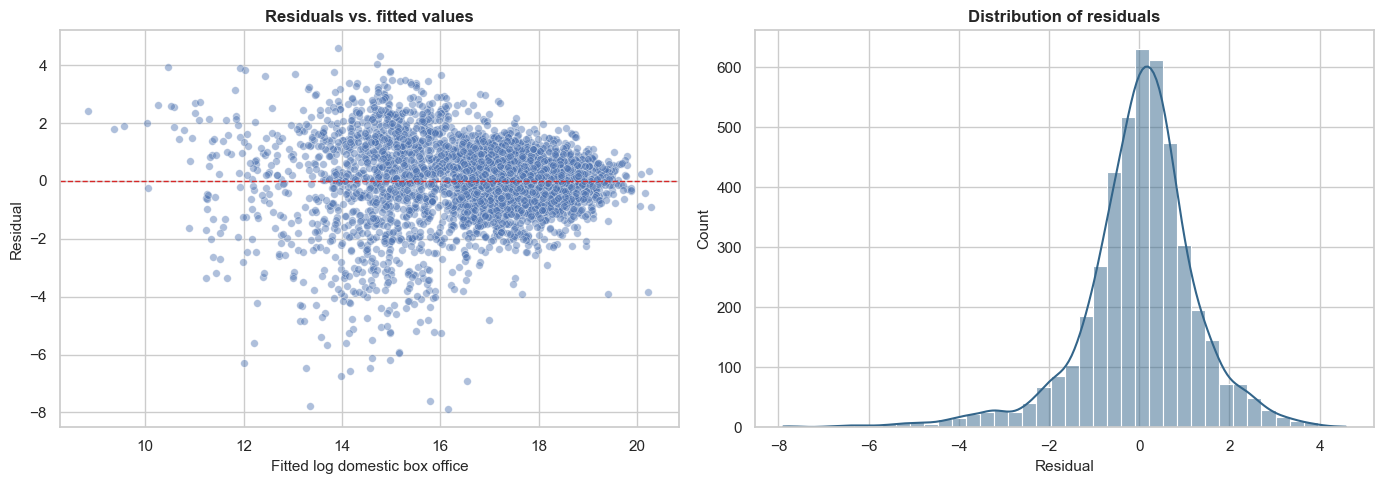

In [20]:
eda["fitted_log_domestic"] = eda_model.fittedvalues
eda["residual_log_domestic"] = eda_model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x=eda["fitted_log_domestic"],
    y=eda["residual_log_domestic"],
    alpha=0.45,
    s=30,
    ax=axes[0],
)
axes[0].axhline(0, color="#D62828", linestyle="--", linewidth=1)
axes[0].set_title("Residuals vs. fitted values")
axes[0].set_xlabel("Fitted log domestic box office")
axes[0].set_ylabel("Residual")

sns.histplot(eda["residual_log_domestic"], bins=40, kde=True, ax=axes[1], color="#33658A")
axes[1].set_title("Distribution of residuals")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()


## EDA Takeaways

1. The cleaned dataset is complete for the variables examined here and is suitable for regression preparation.
2. Domestic box office revenue, worldwide revenue, opening weekend revenue, and production budget are highly skewed on the raw dollar scale, so log transformations are appropriate for the main model.
3. Opening theater count has a clear positive association with domestic box office revenue, especially on the log-log scale.
4. Budget, franchise status, genre, MPAA rating, release quarter, source, production method, creative type, runtime, and release year all look relevant as controls.
5. Post-release variables such as opening weekend revenue, max theaters, legs, average weeks per theater, and worldwide/international box office should not be included as ordinary controls in the main regression unless the estimand is intentionally changed.
